Using device: cuda

Loading test data...

Loaded train set:
  Total clips: 5019
  Fall clips: 2280
  No-fall clips: 2739

Loaded val set:
  Total clips: 1106
  Fall clips: 474
  No-fall clips: 632

Loaded test set:
  Total clips: 1073
  Fall clips: 457
  No-fall clips: 616
  LSTM v5 — Test Set Results
              precision    recall  f1-score   support

     No Fall     0.9117    0.8880    0.8997       616
        Fall     0.8541    0.8840    0.8688       457

    accuracy                         0.8863      1073
   macro avg     0.8829    0.8860    0.8842      1073
weighted avg     0.8872    0.8863    0.8865      1073

Confusion Matrix:
  TN=547  FP=69
  FN=53  TP=404

Inference time: 0.639s total | 0.60 ms/sample

  Rule-Based Baseline — Test Set Results
              precision    recall  f1-score   support

     No Fall     0.8387    0.7597    0.7973       616
        Fall     0.7126    0.8031    0.7551       457

    accuracy                         0.7782      1073
   macro avg 

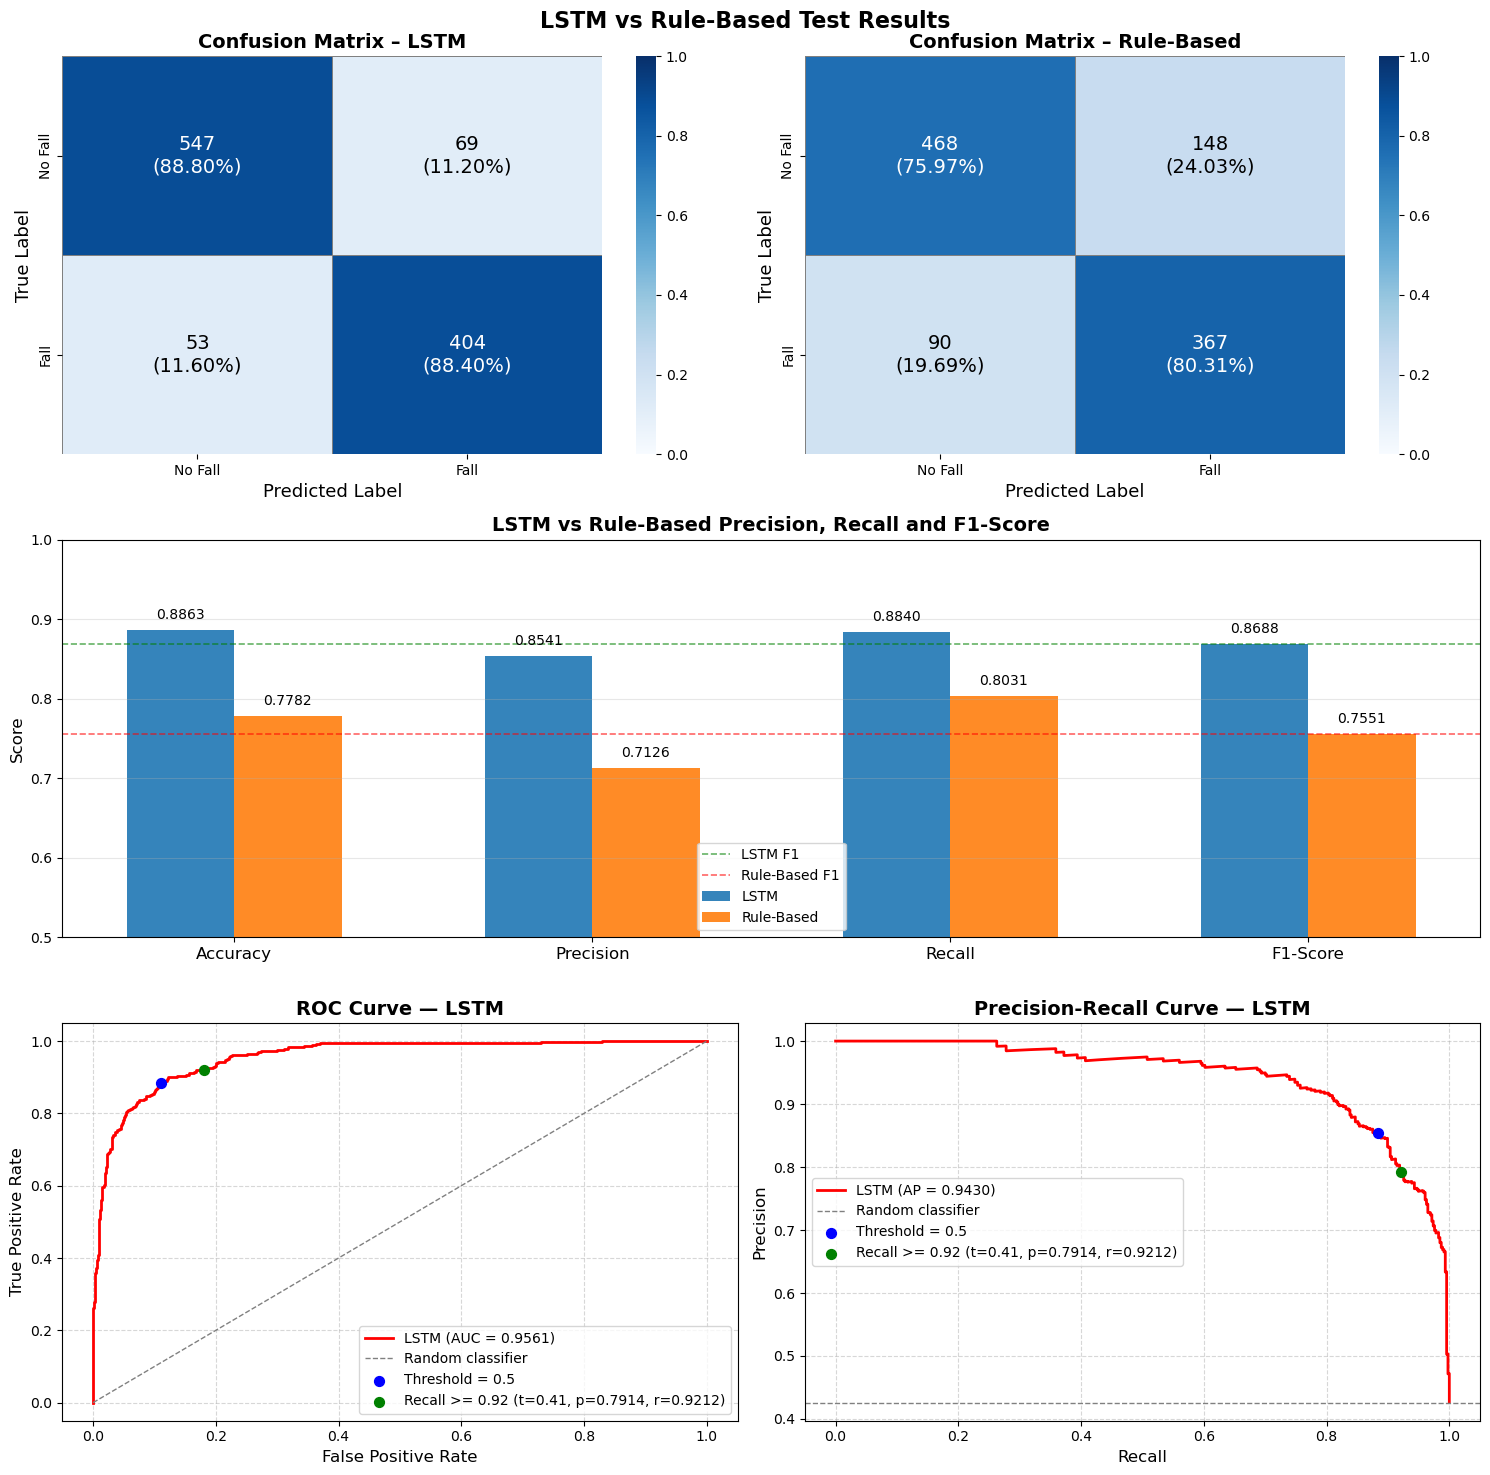

In [50]:
import time
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve, average_precision_score
from dataset import create_dataloaders

# LSTM model definition (must match final version exactly)
class FallDetectionLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        super(FallDetectionLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.fc1 = nn.Linear(hidden_size, 64)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(64, 2)

    def forward(self, x):
        batch_size = x.size(0)
        x = x.view(batch_size, 60, -1)

        lstm_out, (h_n, c_n) = self.lstm(x)
        last_hidden = h_n[-1]

        out = self.fc1(last_hidden)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)

        return out

# MAIN
SPLIT_FILE = 'data/dataset_split.json'
LSTM_CHECKPOINT = 'models/lstm_v5/best_model.pth'
BATCH_SIZE = 32
NUM_WORKERS = 4

INPUT_SIZE = 51
HIDDEN_SIZE = 128
NUM_LAYERS = 2
DROPOUT = 0.4

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}\n")

lstm = dict(name="LSTM")
rb = dict(name="Rule-Based")

# Load test dataloader
print("Loading test data...")
_, _, test_loader = create_dataloaders(
    split_file=SPLIT_FILE,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    normalise=True
)
# -----------------------------------------------------------------------
# LSTM v5 evaluation
print("=" * 55)
print("  LSTM v5 — Test Set Results")
print("=" * 55)

# Load saved model checkpoint
model = FallDetectionLSTM(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, DROPOUT)
checkpoint = torch.load(LSTM_CHECKPOINT, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()

lstm['preds'] = []
lstm['labels'] = []
lstm['probs'] = []
t0 = time.perf_counter() # Start time
# Iterate through test set
with torch.no_grad():
    for batch in test_loader:
        keypoints = batch['keypoints'].to(device)
        labels = batch['label'].cpu().numpy()

        outputs = model(keypoints)
        #_, preds = torch.max(outputs, 1)
        probs = torch.softmax(outputs, dim=1)[:, 1]
        preds = (probs >= 0.5).long()
        lstm['probs'].extend(probs.cpu().numpy())
        
        lstm['preds'].extend(preds.cpu().numpy())
        lstm['labels'].extend(labels)
lstm['time'] = time.perf_counter() - t0 # End time

lstm['preds'] = np.array(lstm['preds'])
lstm['labels'] = np.array(lstm['labels'])
lstm['total'] = len(lstm['labels'])

print(classification_report(lstm['labels'], lstm['preds'], target_names=['No Fall', 'Fall'], digits=4))

lstm['cm'] = confusion_matrix(lstm['labels'], lstm['preds'])
lstm['tn'], lstm['fp'], lstm['fn'], lstm['tp'] = lstm['cm'].ravel()
print(f"Confusion Matrix:")
print(f"  TN={lstm['tn']}  FP={lstm['fp']}")
print(f"  FN={lstm['fn']}  TP={lstm['tp']}")
print(f"\nInference time: {lstm['time']:.3f}s total | {lstm['time']/lstm['total']*1000:.2f} ms/sample")

# -----------------------------------------------------------------------
# Rule-based evaluation
print("\n" + "=" * 55)
print("  Rule-Based Baseline — Test Set Results")
print("=" * 55)
# Copies exact code from rule-based model
LEFT_SHOULDER = 5
RIGHT_SHOULDER = 6
LEFT_HIP = 11
RIGHT_HIP = 12

HIP_DESCENT_THRESHOLD = 0.1 # Rule 1: hip descent across full clip (from average in first 10 frames to average in last 10 frames)
BODY_HORIZONTAL_THRESHOLD = 0.12 # Rule 2: shoulder to hip vertical gap average in final 10 frames
RAPID_DESCENT_THRESHOLD = 0.02 # Rule 3: hip descent in any 10-frame period

def classify_sequence(sequence):
    hip_y = (sequence[:, LEFT_HIP, 1] + sequence[:, RIGHT_HIP, 1]) / 2
    
    shoulder_y = (sequence[:, LEFT_SHOULDER, 1] + sequence[:, RIGHT_SHOULDER, 1]) / 2
    
    # Rule 1: Overall hip descent
    hip_y_start = np.mean(hip_y[:10]) # Average hip Y in first 10 frames
    hip_y_end = np.mean(hip_y[-10:]) # Average hip Y in last 10 frames
    rule1 = (hip_y_end - hip_y_start) > HIP_DESCENT_THRESHOLD # Rule 1 = True if difference from start to end is higher than the set threshold
    
    # Rule 2: Body orientation (check if body is horizontal)
    shoulder_y_end = np.mean(shoulder_y[-10:])  # Average shoulder Y in last 10 frames
    vertical_gap = abs(shoulder_y_end - hip_y_end) # Vertical gap = average shoulder height in last 10 frames - average hip height in last 10 frames
    rule2 = vertical_gap < BODY_HORIZONTAL_THRESHOLD # If the gap between shoulders and hips is lower than the threshold = assume body is horizontal

    # Rule 3: Rapid 10-frame descent
    rule3 = 0
    for i in range(10, len(hip_y)): # Check every 10-frame period
        if (hip_y[i] - hip_y[i-10]) > RAPID_DESCENT_THRESHOLD: # If hip Y descended (increased) by more than the threshold value, Rule 3 = True
            rule3 = 1
            break
    
    # Voting: classify sequence as fall if 2 or more rules are called (True)
    rules_called = [r for r, called in enumerate([rule1, rule2, rule3], start=1) if called]
    prediction  = 1 if len(rules_called) >= 2 else 0

    return prediction, rules_called


rb['preds'] = []
rb['labels'] = []
rb['rule_counts'] = {1: 0, 2: 0, 3: 0}

t0 = time.perf_counter() # Start time
for batch in test_loader:
    keypoints = batch['keypoints'].cpu().numpy()
    labels = batch['label'].cpu().numpy()

    for i in range(len(labels)):
        pred, rules_called = classify_sequence(keypoints[i])
        rb['preds'].append(pred)
        rb['labels'].append(labels[i])
        for r in rules_called:
            rb['rule_counts'][r] += 1
rb['time'] = time.perf_counter() - t0 # End time

rb['preds'] = np.array(rb['preds'])
rb['labels'] = np.array(rb['labels'])

print(classification_report(rb['labels'], rb['preds'], target_names=['No Fall', 'Fall'], digits=4))

rb['cm'] = confusion_matrix(rb['labels'], rb['preds'])
rb['tn'], rb['fp'], rb['fn'], rb['tp'] = rb['cm'].ravel()
print(f"Confusion Matrix:")
print(f"  TN={rb['tn']}  FP={rb['fp']}")
print(f"  FN={rb['fn']}  TP={rb['tp']}")

print(f"\nRule calling counts (out of {len(rb['labels'])} sequences):")
for rule, count in rb['rule_counts'].items():
    print(f"  Rule {rule}: called {count} times ({count / len(rb['labels']) * 100:.1f}%)")

print(f"\nInference time: {rb['time']:.3f}s total | {rb['time']/len(rb['labels'])*1000:.2f} ms/sample")

# -----------------------------------------------------------------------
# Side-by-side summary
def get_metrics(labels, preds):
    acc = accuracy_score(labels, preds)
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average='binary', zero_division=0)
    return acc, p, r, f1

lstm['acc'], lstm['precision'], lstm['recall'], lstm['f1'] = get_metrics(lstm['labels'], lstm['preds'])
rb['acc'], rb['precision'], rb['recall'], rb['f1'] = get_metrics(rb['labels'], rb['preds'])

print("\n" + "=" * 55)
print(f"{'Metric':<22} {'LSTM v5':>15} {'Rule-based':>15}")
print("=" * 55)
rows = [
    ("Accuracy", lstm['acc'], rb['acc']),
    ("Precision (fall)", lstm['precision'], rb['precision']),
    ("Recall (fall)", lstm['recall'], rb['recall']),
    ("F1 (fall)", lstm['f1'], rb['f1']),
    ("ms / sample", lstm['time']/lstm['total']*1000, rb['time']/len(rb['labels'])*1000),
]
for name, lv, rv in rows:
    print(f"{name:<22} {lv:>15.4f} {rv:>15.4f}")
print("=" * 55)
# -----------------------------------------------------------------------
# Graphs
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
fig.suptitle('LSTM vs Rule-Based Test Results', fontsize=16, fontweight='bold')

# Side-by-side graphs
classes = ['No Fall', 'Fall']
for n, model in enumerate([lstm, rb]):
    cm = [[model['tn'], model['fp']], [model['fn'], model['tp']]]
    cm = np.array(cm)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=False, cmap='Blues', xticklabels=classes, yticklabels=classes, linewidths=0.5, linecolor='grey', ax=axes[0, n], vmin=0, vmax=1)
    for i in range(2):
        for j in range(2):
            count = cm[i, j]
            pct = cm_norm[i, j] * 100
            colour = 'white' if cm_norm[i, j] > 0.5 else 'black'
            axes[0, n].text(j + 0.5, i + 0.5, f'{count}\n({pct:.2f}%)', ha='center', va='center', fontsize=14, color=colour)
    axes[0, n].set_xlabel('Predicted Label', fontsize=13)
    axes[0, n].set_ylabel('True Label', fontsize=13)
    name = model['name']
    axes[0, n].set_title(f'Confusion Matrix – {name}', fontsize=14, fontweight='bold')

# -----------------------------------------------------------------------
# Bar Graph Plot
axes[1, 0].remove()
axes[1, 1].remove()
ax_bar = plt.subplot2grid((3, 2), (1, 0), colspan=2, fig=fig)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
lstm_vals = [lstm['acc'], lstm['precision'], lstm['recall'], lstm['f1']]
rb_vals = [rb['acc'], rb['precision'], rb['recall'], rb['f1']]

x = np.arange(len(metrics))
width = 0.3

bars_lstm = ax_bar.bar(x - width/2, lstm_vals, width, label=lstm['name'], alpha=0.9)
bars_rb = ax_bar.bar(x + width/2, rb_vals, width, label=rb['name'], alpha=0.9)

for bars in [bars_lstm, bars_rb]:
    for bar in bars:
        h = bar.get_height()
        ax_bar.text(bar.get_x() + (bar.get_width() / 2), h + 0.01, f'{h:.4f}', ha='center', va='bottom', fontsize=10)

ax_bar.axhline(y=lstm['f1'], color='green', linestyle='--', alpha=0.6, linewidth=1.2, label='LSTM F1')
ax_bar.axhline(y=rb['f1'], color='red', linestyle='--', alpha=0.6, linewidth=1.2, label='Rule-Based F1')
ax_bar.set_xticks(x)
ax_bar.set_xticklabels(metrics, fontsize=12)
ax_bar.set_ylabel('Score', fontsize=12)
ax_bar.set_ylim(0.5, 1)
ax_bar.set_title('LSTM vs Rule-Based Accuracy, Precision, Recall and F1-Score', fontsize=14, fontweight='bold')
ax_bar.legend(loc='lower center', fontsize=10)
ax_bar.grid(axis='y', alpha=0.3)

# -----------------------------------------------------------------------
# ROC Curve Plot
fpr, tpr, roc_thresholds = roc_curve(lstm['labels'], lstm['probs'])
roc_auc = auc(fpr, tpr)

closest_idx = np.argmin(np.abs(roc_thresholds - 0.5))

axes[2, 0].plot(fpr, tpr, color='red', lw=2, label=f'LSTM (AUC = {roc_auc:.4f})')
axes[2, 0].plot([0, 1], [0, 1], color='grey', lw=1, linestyle='--', label='Random classifier')
axes[2, 0].scatter(fpr[closest_idx], tpr[closest_idx], color='blue', s=50, zorder=100, label='Threshold = 0.5')
axes[2, 0].set_xlabel('False Positive Rate', fontsize=12)
axes[2, 0].set_ylabel('True Positive Rate', fontsize=12)
axes[2, 0].set_title('ROC Curve — LSTM', fontsize=14, fontweight='bold')
axes[2, 0].legend(fontsize=10)
axes[2, 0].grid(True, linestyle='--', alpha=0.5)

# -----------------------------------------------------------------------
# Precision-Recall Curve Plot
pr_precision, pr_recall, pr_thresholds = precision_recall_curve(lstm['labels'], lstm['probs'])
avg_precision = average_precision_score(lstm['labels'], lstm['probs'])

axes[2, 1].plot(pr_recall, pr_precision, color='red', lw=2, label=f'LSTM (AP = {avg_precision:.4f})')
axes[2, 1].axhline(y=sum(lstm['labels'])/len(lstm['labels']), color='grey', lw=1, linestyle='--', label='Random classifier')
axes[2, 1].scatter(lstm['recall'], lstm['precision'], color='blue', s=50, zorder=100, label='Threshold = 0.5')
axes[2, 1].set_xlabel('Recall', fontsize=12)
axes[2, 1].set_ylabel('Precision', fontsize=12)
axes[2, 1].set_title('Precision-Recall Curve — LSTM', fontsize=14, fontweight='bold')

target_recall = 0.92
valid = [i for i, r in enumerate(pr_recall[:-1]) if r >= target_recall]
if len(valid) > 0:
    best_idx = valid[np.argmax(pr_precision[valid])]
    opt_threshold = pr_thresholds[best_idx]
    opt_recall = pr_recall[best_idx]
    opt_precision = pr_precision[best_idx]

    roc_idx = np.argmin(np.abs(roc_thresholds - opt_threshold))
    axes[2, 0].scatter(fpr[roc_idx], tpr[roc_idx], color='green', s=50, zorder=100,
                       label=f'Recall >= 0.92 (t={opt_threshold:.2f}, p={opt_precision:.4f}, r={opt_recall:.4f})')
    axes[2, 0].legend(fontsize=10)

    axes[2, 1].scatter(opt_recall, opt_precision, color='green', s=50, zorder=100,
                       label=f'Recall >= 0.92 (t={opt_threshold:.2f}, p={opt_precision:.4f}, r={opt_recall:.4f})')

axes[2, 1].legend(fontsize=10)
axes[2, 1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()

# Save figure
plt.savefig('evaluation_graphs.png', dpi=300, bbox_inches='tight')
print(f"! Evaluation graphs saved to: evaluation_graphs.png")

plt.show()